In [96]:
%pip install -r requirements.txt

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import warnings

GATE30_COLOR = '#378ADD'
GATE40_COLOR = '#D85A30'

In [98]:
df = pd.read_csv('../data/cookie_cats.txt')

print(f'Rows: {len(df)}')
print(df.dtypes)
df.head(10)

Rows: 90189
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
6,1066,gate_30,0,False,False
7,1444,gate_40,2,False,False
8,1574,gate_40,108,True,True
9,1587,gate_40,153,True,False


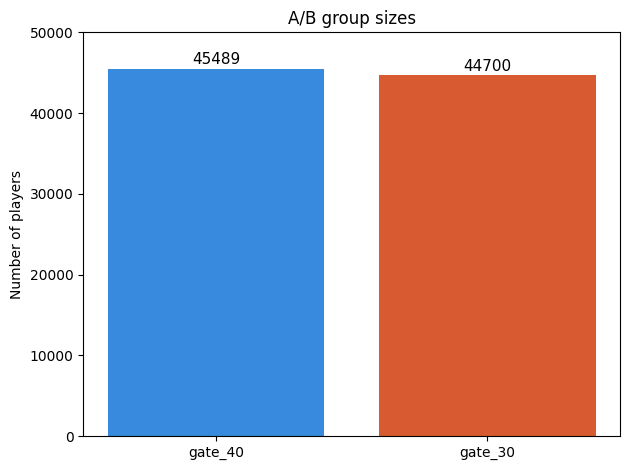

In [99]:
group_counts = df['version'].value_counts()
fig, ax = plt.subplots()
bars = ax.bar(group_counts.index, group_counts.values, color=[GATE30_COLOR, GATE40_COLOR])
ax.set_title('A/B group sizes')
ax.set_ylabel('Number of players')
ax.set_ylim((0, 50000))
for bar, count in zip(bars, group_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, count, ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('../visuals/group_balance.png', dpi=150, bbox_inches='tight')
plt.show()

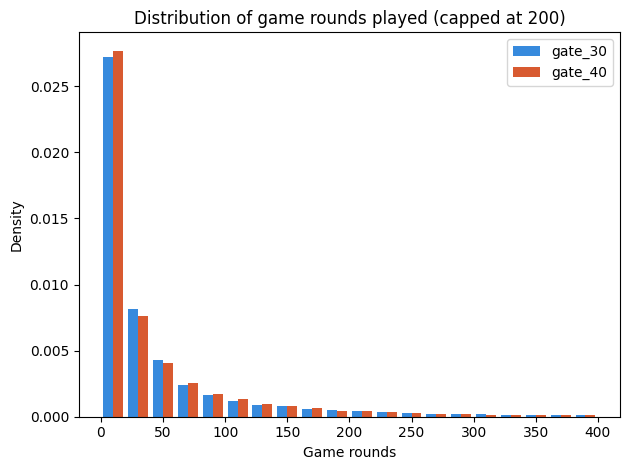

In [100]:
df_plot = df[df['sum_gamerounds'] <= 400]
dat = [df_plot[df_plot['version'] == 'gate_30']['sum_gamerounds'], df_plot[df_plot['version'] == 'gate_40']['sum_gamerounds']]

fig, ax = plt.subplots()
ax.hist(dat, bins=20, label=["gate_30", "gate_40"], color=[GATE30_COLOR, GATE40_COLOR], density=True)
ax.set_title('Distribution of game rounds played (capped at 200)')
ax.set_xlabel('Game rounds')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../visuals/rounds_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
cols = ['retention_1', 'retention_7']
retention_30 = df_plot[df_plot['version'] == 'gate_30'][cols].mean() * 100
retention_40 = df_plot[df_plot['version'] == 'gate_40'][cols].mean() * 100
print(retention_30)
print(retention_40)

fig, ax = plt.subplots()
retention_30 = plt.bar([0, 1], retention_30, width=0.4, color=GATE30_COLOR, label='gate_30')
retention_40 = plt.bar([0.4, 1.4], retention_40, width=0.4, color=GATE40_COLOR, label='gate_40')

ax.set_xticks([0.2, 1.2], cols)
ax.set_ylim((0, 50))
ax.set_ylabel("Retention Rate (%)")
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/retention_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def chi_squared_test(df, retention_col):
    contingency = pd.crosstab(df['version'], df[retention_col])
    chi2, p, dof, expected_freq = stats.chi2_contingency(contingency)
    print(retention_col)
    print(f'Chi2 statistic : {chi2}')
    print(f'P-value        : {p}')
    print()
    return p

p1 = chi_squared_test(df, 'retention_1')
p7 = chi_squared_test(df, 'retention_7')

In [ ]:
def bootstrap_diff(df, retention_col, n_iterations=5000, seed=67):
    np.random.seed(seed)
    gate30 = df[df['version'] == 'gate_30'][retention_col]
    gate40 = df[df['version'] == 'gate_40'][retention_col]
    
    diffs = []
    for i in range(n_iterations):
        sample30 = np.random.choice(gate30, size=len(gate30), replace=True)
        sample40 = np.random.choice(gate40, size=len(gate40), replace=True)
        diffs.append((sample30.mean() - sample40.mean()) * 100)
    
    ci_lower, ci_upper = np.percentile(diffs, [2.5, 97.5])
    observed_diff = (gate30.mean() - gate40.mean()) * 100
    
    print(retention_col)
    print(f'Observed difference    : {observed_diff}%')
    print(f'95% Confidence interval: [{ci_lower}, {ci_upper}]%')
    print()
    return diffs, observed_diff, ci_lower, ci_upper

diffs_1, obs_1, ci1_lo, ci1_hi = bootstrap_diff(df, 'retention_1')
diffs_7, obs_7, ci7_lo, ci7_hi = bootstrap_diff(df, 'retention_7')

In [ ]:
# Bootstrap distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, diffs, obs, ci_lo, ci_hi, title in zip(
    axes,
    [diffs_1, diffs_7],
    [obs_1, obs_7],
    [ci1_lo, ci7_lo],
    [ci1_hi, ci7_hi],
    ['1-day retention', '7-day retention']
):
    ax.hist(diffs, bins=60, color=GATE30_COLOR, alpha=0.7)
    ax.axvline(obs, color='black', linewidth=1.5, linestyle='--', alpha=0.5, label=f'Observed: {obs:.3f} pp')
    ax.axvline(ci_lo, color=GATE40_COLOR, linewidth=1.2, linestyle=':', label=f'95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]')
    ax.axvline(ci_hi, color=GATE40_COLOR, linewidth=1.2, linestyle=':')
    ax.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.7, label='No difference')
    ax.set_xlim(-2, 2)
    ax.set_title(f'Bootstrap distribution — {title}')
    ax.set_xlabel('Difference in retention rate (%)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../visuals/bootstrap_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def engagement_segment(rounds):
    if rounds == 0:
        return 0
    elif rounds <= 30:
        return 1
    elif rounds <= 100:
        return 2
    else:
        return 3
segment_labels = ['0 - No engagement','1 - Casual (1-30)','2 - Mid-core (31-100)','3 - Hardcore (100+)']
df['segment'] = df['sum_gamerounds'].apply(engagement_segment)
print(df['segment'].value_counts().sort_index())
df.head(10)

In [ ]:
for i in np.sort(df['segment'].unique()):
    print(f"Chi Squared Test on player segment {i}")
    df[df['segment'] == i]
    chi_squared_test(df[df['segment'] == i], 'retention_1')
    chi_squared_test(df[df['segment'] == i], 'retention_7')

In [ ]:
seg = df.groupby(['segment', 'version'])[['retention_1', 'retention_7']].mean() * 100
seg = seg.reset_index()
print(seg)

seg_30 = seg[seg['version'] == 'gate_30'].set_index('segment')
seg_40 = seg[seg['version'] == 'gate_40'].set_index('segment')
seg_diff = seg_30[['retention_1', 'retention_7']] - seg_40[['retention_1', 'retention_7']]

cols = ['retention_1', 'retention_7']
segments = np.sort(df['segment'].unique())
retention_30 = df_plot[df_plot['version'] == 'gate_30'][cols].mean() * 100
retention_40 = df_plot[df_plot['version'] == 'gate_40'][cols].mean() * 100

fig, axs = plt.subplots(1, len(cols), figsize=(11, 5))
for i in range(len(cols)):
    retention_30 = axs[i].bar([0, 1, 2, 3], seg_30[cols[i]], width=0.4, color=GATE30_COLOR, label='gate_30')
    retention_40 = axs[i].bar([0.4, 1.4, 2.4, 3.4], seg_40[cols[i]], width=0.4, color=GATE40_COLOR, label='gate_40')
    axs[i].set_xticks([0.2, 1.2, 2.2, 3.2], segment_labels, rotation=45)
    axs[i].set_ylim((0, 100))
    days = 1 if i == 0 else 7
    axs[i].set_title(f'Observed Retention Rate ({days}-day retention)')
    axs[i].set_ylabel("Retention Rate (%)")
    axs[i].set_xlabel("Player Segment")
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/retention_segmented_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axs = plt.subplots(1, len(cols), figsize=(11, 5))
obs_30 = []
obs_40 = []
for segment in segments:
    subset = df[df['segment'] == segment]
    
    diffs, obs, ci_lo, ci_hi = bootstrap_diff(subset, 'retention_1', n_iterations=2000)
    conclusion = 'gate_30 better' if ci_lo > 0 else ('gate_40 better' if ci_hi < 0 else 'inconclusive')
    print(f'{segment}: {conclusion}')
    print()
    obs_30.append(diffs)

    diffs, obs, ci_lo, ci_hi = bootstrap_diff(subset, 'retention_7', n_iterations=2000)
    conclusion = 'gate_30 better' if ci_lo > 0 else ('gate_40 better' if ci_hi < 0 else 'inconclusive')
    print(f'{segment}: {conclusion}')
    print()
    obs_40.append(diffs)
    
axs[0].boxplot(obs_30, tick_labels=segments, patch_artist=True)
axs[0].axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.7, label='No difference')
axs[0].set_xticklabels(segment_labels, rotation=45)
axs[0].set_title(f'Bootstrap distribution (1-day retention)')
axs[0].set_xlabel('Difference in retention rate (%)')
axs[0].set_ylabel('Player Segment')

axs[1].boxplot(obs_40, tick_labels=segments, patch_artist=True)
axs[1].axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.7, label='No difference')
axs[1].set_title(f'Bootstrap distribution (7-day retention)')
axs[1].set_xticklabels(segment_labels, rotation=45)
axs[1].set_xlabel('Difference in retention rate (%)')
axs[1].set_ylabel('Player Segment')
plt.tight_layout()
plt.savefig('../visuals/bootstrap_distributions_segmented.png', dpi=150, bbox_inches='tight')
plt.show()

# Recommendation

### What we tested
Cookie Cats ran an A/B test on 90,189 players separated unto 4 different player segments based on played rounds to evaluate whether moving the first progression gate from level 30 to level 40 improved player retention.

### What we found
#### 1-day retention
| Metric | Gate 30 | Gate 40 | Difference | Significant? |
|---|---|---|---|---|
| 0 - No engagement | 2.11% | 2.23% | -0.12% | No |
| 1 - Casual (1-30) | 25.86% | 25.68% | 0.18% | No |
| 2 - Mid-core (31-100) | 74.69% | 74.63% | 0.06% | No |
| 3 - Hardcore (100+) | 90.20% | 89.78% | 0.42% | No |

#### 7-day retention
| Metric | Gate 30 | Gate 40 | Difference | Significant? |
|---|---|---|---|---|
| 0 - No engagement | 0.82% | 0.63% | 0.19% | No |
| 1 - Casual (1-30) | 4.62% | 4.30% | 0.32% | No |
| 2 - Mid-core (31-100) | 28.40% | 26.22% | 2.18% | Yes |
| 3 - Hardcore (100+) | 71.38% | 71.24% | 0.14% | No |

Bootstrap confidence intervals for 7-day on mid-core players retention sit entirely above zero, meaning gate_30 is reliably better with 95% confidence. The 1-day results and results for other player segments are less conclusive.

### Recommendation: Keep the gate at level 30

The data suggest that players who hit the gate (mid-core players) but not hard core enough to push through level 100 are negatively impacted in the long term by the change in the level gate. Players who hit the gate early are more likely to return, possibly because the interruption creates a "what happens next?" effect (hedonic adaptation theory). Removing the friction too early may actually reduce long-term engagement.

At the scale of this game, a 2.18 percentage point drop in 7-day retention represents thousands of lost returning players per cohort.

### Caveats
- This analysis covers the first 14 days post-install only. Longer-term retention (30-day, 90-day) could tell a different story.
- Revenue impact is not captured in this dataset. Players who reach level 40 uninterrupted may spend more.
- Segment-level analysis (by device, country, acquisition channel) could reveal subgroups that respond differently.